# EEG-Based Alzheimer's Disease Classification

### Random Forest — AD vs Cognitively Normal

This notebook applies a **Random Forest classifier** to the subject-level EEG spectral features generated from the complete OpenNeuro `ds004504` dataset.

**Classification:** Alzheimer's disease (AD) vs Cognitively normal (CN)  
**Subjects:** 65  
**Features:** Delta, Theta, Alpha, Beta, Gamma  
**Model:** Random Forest

In [1]:
print("Today we are going to do Random Forest")

Today we are going to do Random Forest


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/all_subjects_features.csv")

In [4]:
df.head()

,subject,group,age,MMSE,delta,theta,alpha,beta,gamma
0,sub-001,A,57,16,0.345179,0.328017,0.102048,0.129601,0.095154
1,sub-002,A,78,22,0.143655,0.154829,0.464910,0.190827,0.045779
2,sub-003,A,70,14,0.222562,0.231461,0.476515,0.053760,0.015702
3,sub-004,A,67,20,0.420912,0.277658,0.071022,0.123877,0.106531
4,sub-005,A,70,22,0.349276,0.211557,0.170443,0.193253,0.075471


In [5]:
df = df[df["group"].isin(["A", "C"])]

In [6]:
X = df[["delta", "theta", "alpha", "beta", "gamma"]]
y = df["group"]

In [9]:
print("Number of participants:", len(df))
print("\nGroup counts:", y.value_counts())

Number of participants: 65

Group counts: group
A    36
C    29
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
from sklearn.ensemble import RandomForestClassifier

In [13]:
model = RandomForestClassifier(
    random_state=42
)

In [15]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [16]:
y_pred = model.predict(X_test)

In [17]:
print("Actual:", y_test.to_numpy())
print("Predicted:", y_pred)

Actual: ['A' 'C' 'C' 'A' 'C' 'A' 'C' 'A' 'A' 'C' 'A' 'C' 'A']
Predicted: ['A' 'C' 'C' 'C' 'C' 'A' 'C' 'A' 'A' 'C' 'A' 'C' 'C']


In [18]:
from sklearn.metrics import accuracy_score

In [19]:
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.8461538461538461


In [20]:
from sklearn.metrics import confusion_matrix

In [21]:
cm = confusion_matrix(y_test, y_pred, labels=["A", "C"])
print(cm)

[[5 2]
 [0 6]]


In [22]:
from sklearn.metrics import classification_report

In [23]:
print(classification_report(y_test, y_pred, target_names=["AD", "CN"]))

              precision    recall  f1-score   support

          AD       1.00      0.71      0.83         7
          CN       0.75      1.00      0.86         6

    accuracy                           0.85        13
   macro avg       0.88      0.86      0.85        13
weighted avg       0.88      0.85      0.84        13



In [24]:
from sklearn.metrics import roc_auc_score

In [25]:
y_prob = model.predict_proba(X_test)
y_prob_c = y_prob[:, 1]

In [26]:
auc = roc_auc_score(y_test, y_prob_c)
print("ROC-AUC:", auc)

ROC-AUC: 0.8571428571428572


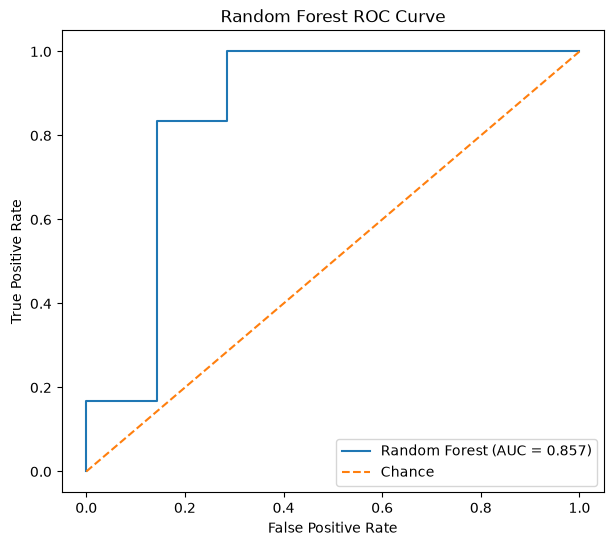

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_c,
    pos_label="C"
)

auc = roc_auc_score(y_test, y_prob_c)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.grid(False)
plt.show()

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("CV Standard Deviation:", cv_scores.std())

CV Scores: [0.54545455 0.72727273 0.9        0.8        0.9       ]
Mean CV Accuracy: 0.7745454545454545
CV Standard Deviation: 0.13178996563214637


In [28]:
from sklearn.model_selection import GridSearchCV

In [31]:
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [32]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [33]:
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

In [34]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for

In [35]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.7927272727272727


In [36]:
best_model = grid_search.best_estimator_
print(best_model)

RandomForestClassifier(max_depth=5, random_state=42)


In [39]:
y_pred_tuned = best_model.predict(X_test)

In [40]:
print("Actual:", y_test.to_numpy())
print("Predicted:", y_pred_tuned)

Actual: ['A' 'C' 'C' 'A' 'C' 'A' 'C' 'A' 'A' 'C' 'A' 'C' 'A']
Predicted: ['A' 'C' 'C' 'C' 'C' 'A' 'C' 'A' 'A' 'C' 'A' 'C' 'C']


In [41]:
from sklearn.metrics import accuracy_score

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print("Tuned Random Forest Test Accuracy:", tuned_accuracy)

Tuned Random Forest Test Accuracy: 0.8461538461538461


In [42]:
from sklearn.metrics import confusion_matrix

cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned,
    labels=["A", "C"]
)

print(cm_tuned)

[[5 2]
 [0 6]]


In [43]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["AD", "CN"]
))

              precision    recall  f1-score   support

          AD       1.00      0.71      0.83         7
          CN       0.75      1.00      0.86         6

    accuracy                           0.85        13
   macro avg       0.88      0.86      0.85        13
weighted avg       0.88      0.85      0.84        13



In [44]:
from sklearn.metrics import roc_auc_score

y_prob_tuned = best_model.predict_proba(X_test)
y_prob_tuned_c = y_prob_tuned[:, 1]

tuned_auc = roc_auc_score(y_test, y_prob_tuned_c)
print("Tuned Random Forest ROC-AUC:", tuned_auc)

Tuned Random Forest ROC-AUC: 0.8571428571428572


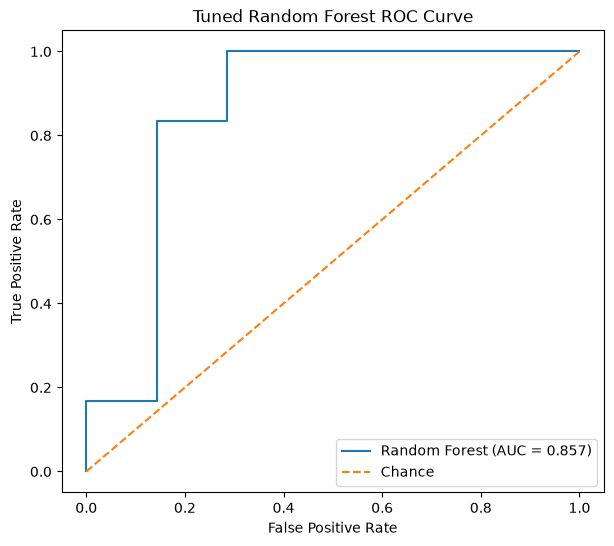

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_tuned, tpr_tuned, thresholds_tuned = roc_curve(
    y_test,
    y_prob_tuned_c,
    pos_label="C"
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_tuned,
    tpr_tuned,
    label=f"Random Forest (AUC = {tuned_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned Random Forest ROC Curve")
plt.legend()
plt.grid(False)
plt.show()

In [47]:
rf_results = {
    "model": "Random Forest",
    "test_accuracy": tuned_accuracy,
    "roc_auc": tuned_auc,
    "cv_mean_accuracy": grid_search.best_score_,
    "cv_std_accuracy": grid_search.cv_results_["std_test_score"][grid_search.best_index_],
    "best_n_estimators": grid_search.best_params_["n_estimators"],
    "best_max_depth": grid_search.best_params_["max_depth"],
    "best_min_samples_split": grid_search.best_params_["min_samples_split"],
    "best_min_samples_leaf": grid_search.best_params_["min_samples_leaf"]
}

In [49]:
rf_results_df = pd.DataFrame([rf_results])

In [50]:
rf_results_df.to_csv(
    "../data/random_forest_results.csv",
    index=False
)

In [51]:
print(rf_results_df)

           model  test_accuracy   roc_auc  cv_mean_accuracy  cv_std_accuracy  \
0  Random Forest       0.846154  0.857143          0.792727         0.101786   

   best_n_estimators  best_max_depth  best_min_samples_split  \
0                100               5                       2   

   best_min_samples_leaf  
0                      1  


In [52]:
from pathlib import Path

rf_figures_path = Path("../figures/random_forest")
rf_figures_path.mkdir(parents=True, exist_ok=True)

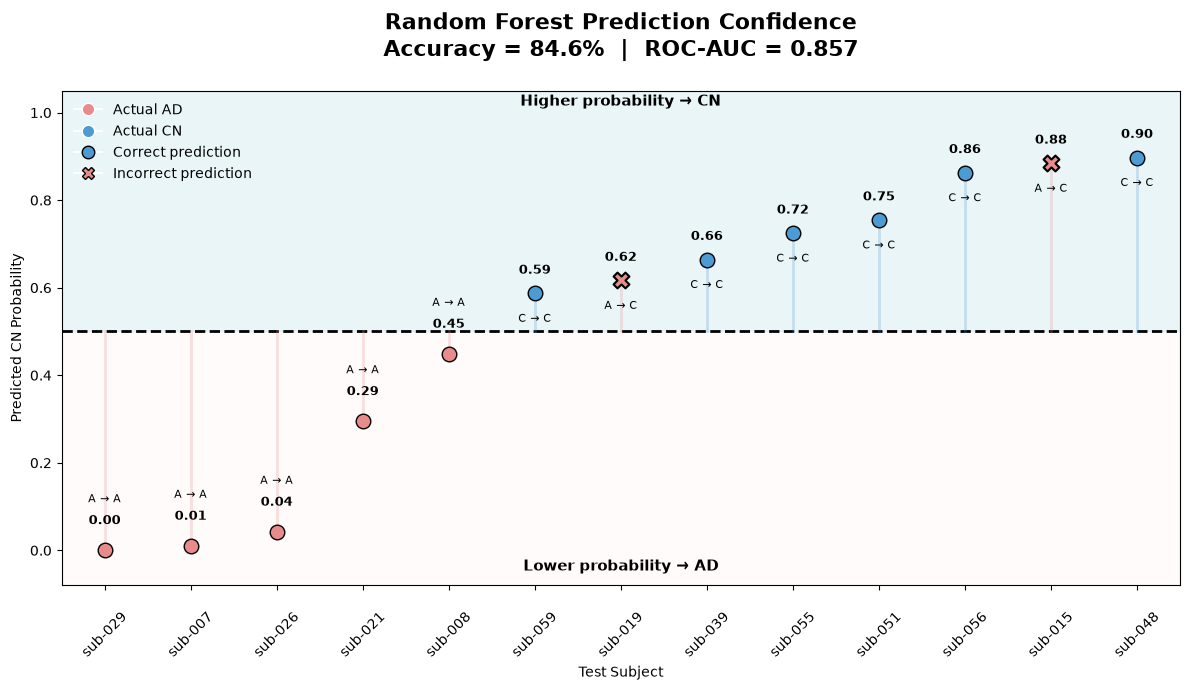

In [59]:
import matplotlib.pyplot as plt
import numpy as np

y_pred_from_prob = np.where(y_prob_tuned_c >= 0.5, "C", "A")

test_subjects = df.loc[y_test.index, "subject"].to_numpy()

order = np.argsort(y_prob_tuned_c)

probabilities = y_prob_tuned_c[order]
actual_groups = y_test.to_numpy()[order]
predicted_groups = y_pred_from_prob[order]
subject_ids = test_subjects[order]

plt.figure(figsize=(12, 7))

plt.axhspan(
    0.5,
    1.05,
    color="lightblue",
    alpha=0.25
)

plt.axhspan(
    -0.08,
    0.5,
    color="mistyrose",
    alpha=0.12
)

plt.axhline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=2
)

for i in range(len(probabilities)):

    probability = probabilities[i]
    actual = actual_groups[i]
    predicted = predicted_groups[i]

    if actual == "A":
        point_color = "#E88B8B"
    else:
        point_color = "#4C9BD3"

    correct = actual == predicted

    plt.plot(
        [i + 1, i + 1],
        [0.5, probability],
        color=point_color,
        alpha=0.25,
        linewidth=2
    )

    if correct:
        plt.scatter(
            i + 1,
            probability,
            s=110,
            color=point_color,
            edgecolors="black",
            linewidths=1,
            marker="o",
            zorder=3
        )
    else:
        plt.scatter(
            i + 1,
            probability,
            s=130,
            color=point_color,
            edgecolors="black",
            linewidths=1.5,
            marker="X",
            zorder=4
        )

    if probability < 0.55:
        probability_offset = 0.06
        group_offset = 0.11
    else:
        probability_offset = 0.045
        group_offset = -0.065

    plt.text(
        i + 1,
        probability + probability_offset,
        f"{probability:.2f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

    plt.text(
        i + 1,
        probability + group_offset,
        f"{actual} → {predicted}",
        ha="center",
        fontsize=8
    )

plt.xticks(
    range(1, len(subject_ids) + 1),
    subject_ids,
    rotation=45
)

plt.tick_params(
    axis="x",
    pad=14
)

plt.subplots_adjust(bottom=0.32)

plt.xlabel("Test Subject")
plt.ylabel("Predicted CN Probability")

plt.title(
    f"Random Forest Prediction Confidence\n"
    f"Accuracy = {tuned_accuracy:.1%}  |  ROC-AUC = {tuned_auc:.3f}",
    fontsize=16,
    fontweight="bold",
    pad=25
)

plt.text(
    0.5,
    0.97,
    "Higher probability → CN",
    transform=plt.gca().transAxes,
    ha="center",
    fontsize=11,
    fontweight="bold"
)

plt.text(
    0.5,
    0.03,
    "Lower probability → AD",
    transform=plt.gca().transAxes,
    ha="center",
    fontsize=11,
    fontweight="bold"
)

correct_legend = plt.Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    markerfacecolor="#4C9BD3",
    markeredgecolor="black",
    markersize=9,
    label="Correct prediction"
)

wrong_legend = plt.Line2D(
    [0],
    [0],
    marker="X",
    color="w",
    markerfacecolor="#E88B8B",
    markeredgecolor="black",
    markersize=9,
    label="Incorrect prediction"
)

actual_ad = plt.Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    markerfacecolor="#E88B8B",
    markersize=9,
    label="Actual AD"
)

actual_cn = plt.Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    markerfacecolor="#4C9BD3",
    markersize=9,
    label="Actual CN"
)

plt.legend(
    handles=[
        actual_ad,
        actual_cn,
        correct_legend,
        wrong_legend
    ],
    loc="upper left",
    frameon=False
)

plt.xlim(
    0.5,
    len(subject_ids) + 0.5
)

plt.ylim(
    -0.08,
    1.05
)

plt.grid(False)
plt.tight_layout()

plt.savefig(
    "../figures/random_forest/prediction_confidence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

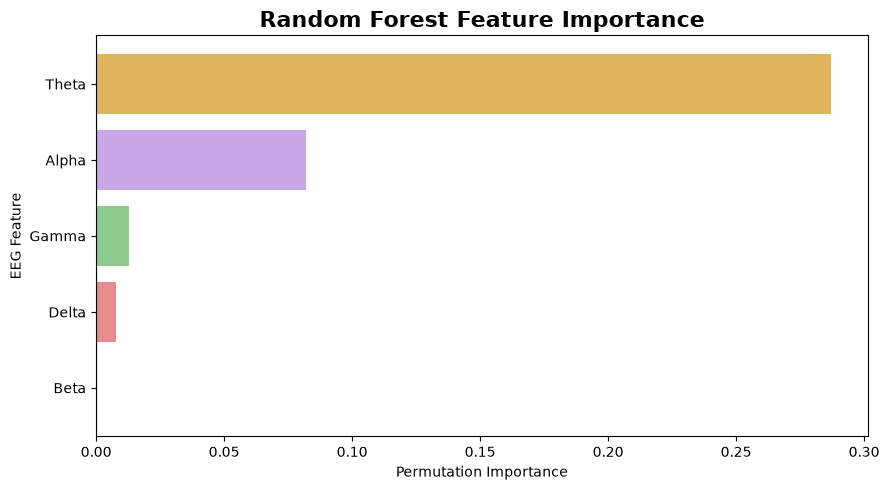

In [62]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="accuracy",
    n_repeats=30,
    random_state=42
)

feature_importance = pd.DataFrame({
    "Feature": ["Delta", "Theta", "Alpha", "Beta", "Gamma"],
    "Importance": result.importances_mean
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color=["#4C9BD3", "#E88B8B", "#8CCB8C", "#C9A7E8", "#E0B45C"]
)

plt.axvline(
    0,
    color="black",
    linewidth=1.5
)

plt.xlabel("Permutation Importance")
plt.ylabel("EEG Feature")
plt.title(
    "Random Forest Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.grid(False)
plt.tight_layout()

plt.savefig(
    "../figures/random_forest/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

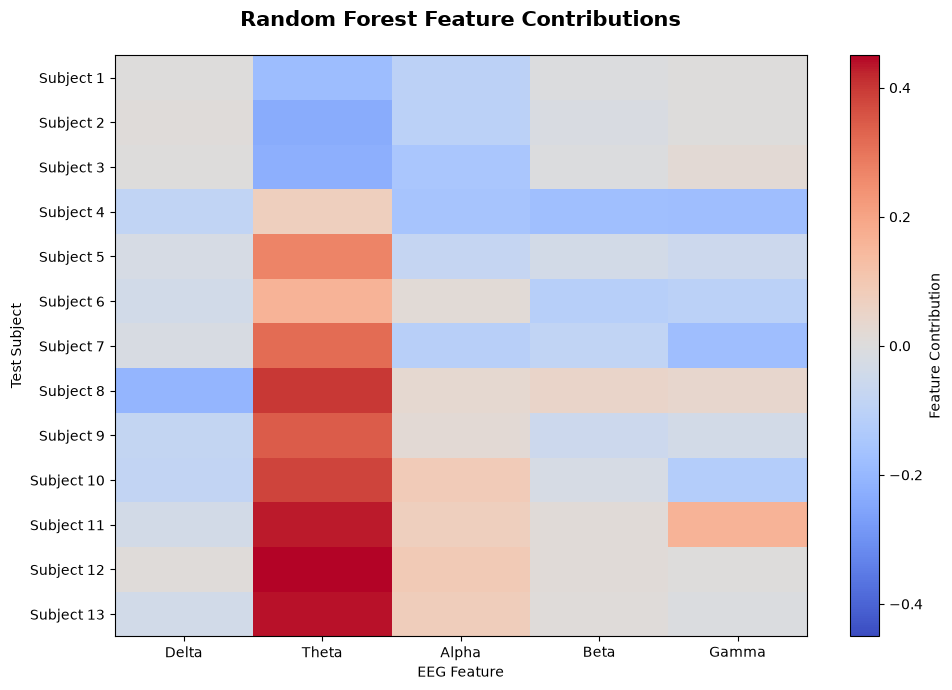

In [64]:
import matplotlib.pyplot as plt
import numpy as np

features = ["delta", "theta", "alpha", "beta", "gamma"]

baseline_probabilities = best_model.predict_proba(X_test)[:, 1]

contributions = np.zeros(
    (len(X_test), len(features))
)

for j, feature in enumerate(features):

    X_test_modified = X_test.copy()

    X_test_modified[feature] = X_train[feature].mean()

    modified_probabilities = best_model.predict_proba(
        X_test_modified
    )[:, 1]

    contributions[:, j] = (
        baseline_probabilities - modified_probabilities
    )

order = np.argsort(baseline_probabilities)

contributions_sorted = contributions[order]

plt.figure(figsize=(10, 7))

max_value = np.max(np.abs(contributions_sorted))

plt.imshow(
    contributions_sorted,
    aspect="auto",
    cmap="coolwarm",
    vmin=-max_value,
    vmax=max_value
)

plt.colorbar(
    label="Feature Contribution"
)

plt.xticks(
    range(len(features)),
    ["Delta", "Theta", "Alpha", "Beta", "Gamma"]
)

plt.yticks(
    range(len(order)),
    [f"Subject {i + 1}" for i in range(len(order))]
)

plt.xlabel("EEG Feature")
plt.ylabel("Test Subject")

plt.title(
    "Random Forest Feature Contributions",
    fontsize=15,
    fontweight="bold",
    pad=21
)

plt.tight_layout()

plt.savefig(
    "../figures/random_forest/feature_contributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

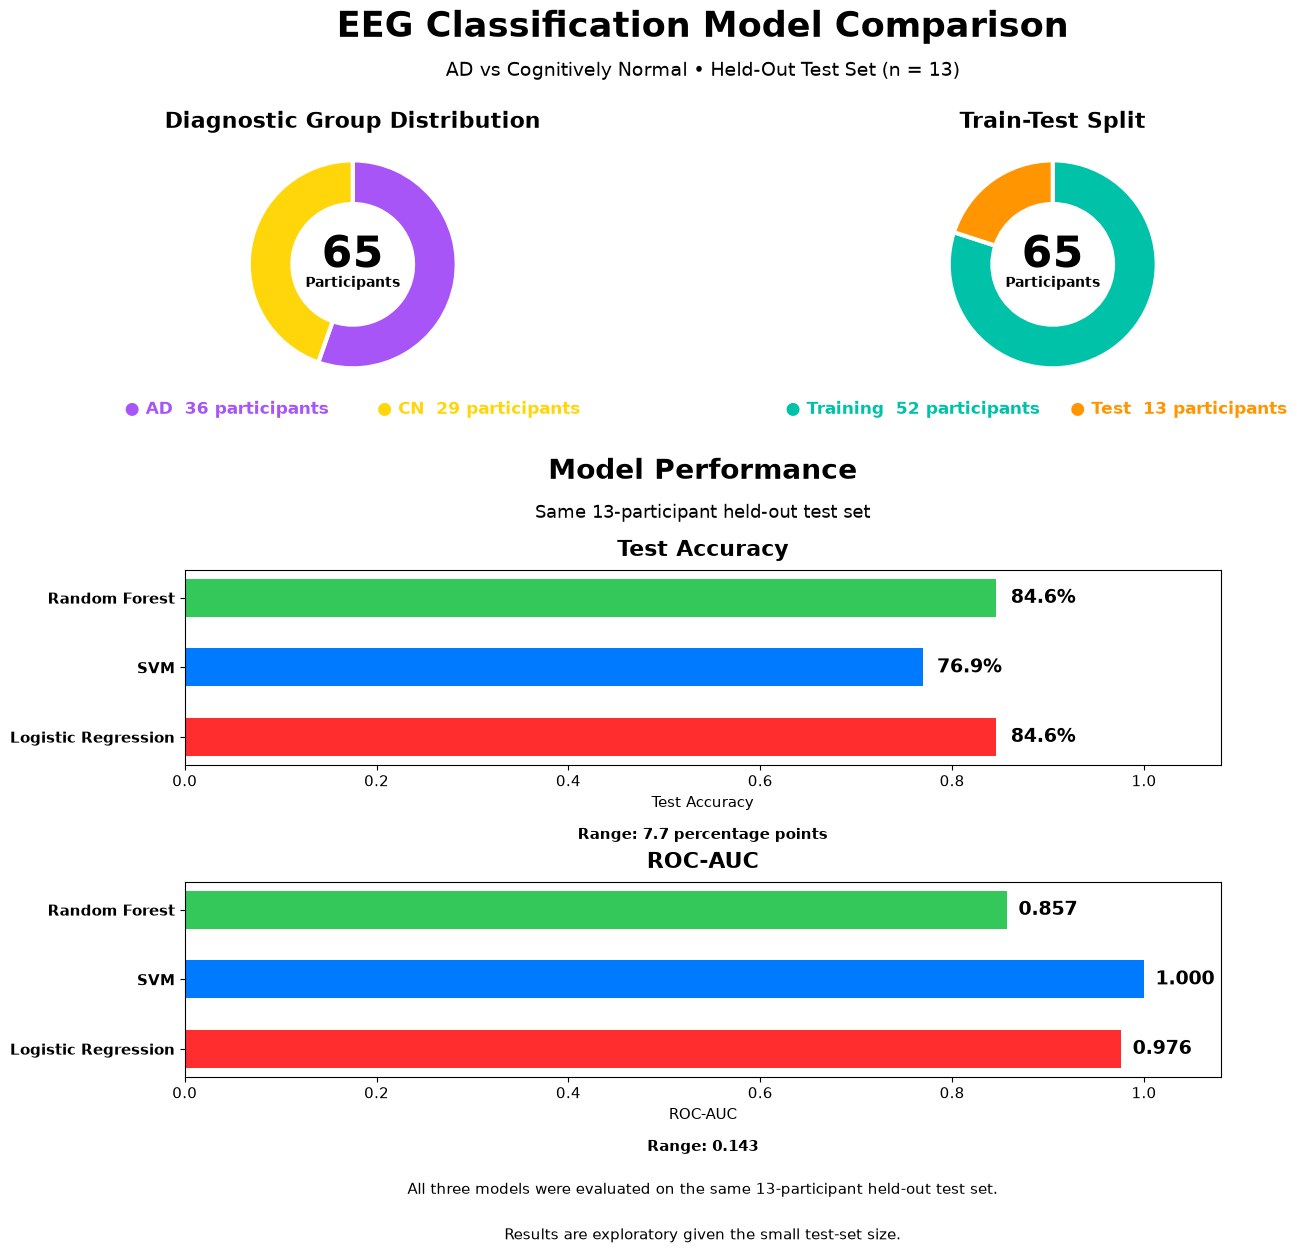

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

logistic_results = pd.read_csv(
    "../data/logistic_regression_results.csv"
)

svm_results = pd.read_csv(
    "../data/svm_results.csv"
)

random_forest_results = pd.read_csv(
    "../data/random_forest_results.csv"
)

logistic_accuracy = logistic_results.loc[0, "test_accuracy"]
logistic_auc = logistic_results.loc[0, "roc_auc"]

svm_accuracy = svm_results.loc[0, "test_accuracy"]
svm_auc = svm_results.loc[0, "roc_auc"]

random_forest_accuracy = random_forest_results.loc[0, "test_accuracy"]
random_forest_auc = random_forest_results.loc[0, "roc_auc"]

logistic_color = "#FF2D2D"
svm_color = "#007AFF"
random_forest_color = "#34C759"

diagnostic_ad_color = "#A855F7"
diagnostic_cn_color = "#FFD60A"

train_color = "#00C2A8"
test_color = "#FF9500"

fig = plt.figure(figsize=(14, 13))
fig.patch.set_facecolor("white")

fig.text(
    0.5,
    0.965,
    "EEG Classification Model Comparison",
    ha="center",
    fontsize=25,
    fontweight="bold"
)

fig.text(
    0.5,
    0.935,
    "AD vs Cognitively Normal • Held-Out Test Set (n = 13)",
    ha="center",
    fontsize=14
)

fig.text(
    0.25,
    0.895,
    "Diagnostic Group Distribution",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.75,
    0.895,
    "Train-Test Split",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

left_ax = fig.add_axes(
    [0.06, 0.690, 0.38, 0.20]
)

left_ax.set_aspect("equal")
left_ax.axis("off")

left_ax.pie(
    [36, 29],
    colors=[
        diagnostic_ad_color,
        diagnostic_cn_color
    ],
    startangle=90,
    counterclock=False,
    radius=1.0,
    wedgeprops={
        "width": 0.42,
        "edgecolor": "white",
        "linewidth": 3
    }
)

left_ax.text(
    0,
    0.08,
    "65",
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold"
)

left_ax.text(
    0,
    -0.18,
    "Participants",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold"
)

fig.text(
    0.16,
    0.675,
    "● AD  36 participants",
    ha="center",
    fontsize=12,
    fontweight="bold",
    color=diagnostic_ad_color
)

fig.text(
    0.34,
    0.675,
    "● CN  29 participants",
    ha="center",
    fontsize=12,
    fontweight="bold",
    color=diagnostic_cn_color
)

right_ax = fig.add_axes(
    [0.56, 0.690, 0.38, 0.20]
)

right_ax.set_aspect("equal")
right_ax.axis("off")

right_ax.pie(
    [52, 13],
    colors=[
        train_color,
        test_color
    ],
    startangle=90,
    counterclock=False,
    radius=1.0,
    wedgeprops={
        "width": 0.42,
        "edgecolor": "white",
        "linewidth": 3
    }
)

right_ax.text(
    0,
    0.08,
    "65",
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold"
)

right_ax.text(
    0,
    -0.18,
    "Participants",
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold"
)

fig.text(
    0.65,
    0.675,
    "● Training  52 participants",
    ha="center",
    fontsize=12,
    fontweight="bold",
    color=train_color
)

fig.text(
    0.84,
    0.675,
    "● Test  13 participants",
    ha="center",
    fontsize=12,
    fontweight="bold",
    color=test_color
)

fig.text(
    0.5,
    0.625,
    "Model Performance",
    ha="center",
    fontsize=20,
    fontweight="bold"
)

fig.text(
    0.5,
    0.595,
    "Same 13-participant held-out test set",
    ha="center",
    fontsize=13
)

models = [
    "Logistic Regression",
    "SVM",
    "Random Forest"
]

model_colors = [
    logistic_color,
    svm_color,
    random_forest_color
]

accuracy_values = [
    logistic_accuracy,
    svm_accuracy,
    random_forest_accuracy
]

accuracy_ax = fig.add_axes(
    [0.13, 0.405, 0.74, 0.15]
)

accuracy_ax.barh(
    models,
    accuracy_values,
    color=model_colors,
    height=0.55
)

accuracy_ax.set_xlim(0, 1.08)

accuracy_ax.set_xlabel(
    "Test Accuracy",
    fontsize=11
)

accuracy_ax.set_title(
    "Test Accuracy",
    fontsize=16,
    fontweight="bold",
    pad=10
)

accuracy_ax.tick_params(
    axis="both",
    labelsize=11
)

for label in accuracy_ax.get_yticklabels():
    label.set_fontweight("bold")

accuracy_ax.grid(False)

for i, value in enumerate(accuracy_values):
    accuracy_ax.text(
        value + 0.015,
        i,
        f"{value * 100:.1f}%",
        va="center",
        fontsize=14,
        fontweight="bold"
    )

accuracy_range = (
    max(accuracy_values) - min(accuracy_values)
)

accuracy_ax.text(
    0.5,
    -0.38,
    f"Range: {accuracy_range * 100:.1f} percentage points",
    transform=accuracy_ax.transAxes,
    ha="center",
    fontsize=11,
    fontweight="bold"
)

auc_values = [
    logistic_auc,
    svm_auc,
    random_forest_auc
]

auc_ax = fig.add_axes(
    [0.13, 0.165, 0.74, 0.15]
)

auc_ax.barh(
    models,
    auc_values,
    color=model_colors,
    height=0.55
)

auc_ax.set_xlim(0, 1.08)

auc_ax.set_xlabel(
    "ROC-AUC",
    fontsize=11
)

auc_ax.set_title(
    "ROC-AUC",
    fontsize=16,
    fontweight="bold",
    pad=10
)

auc_ax.tick_params(
    axis="both",
    labelsize=11
)

for label in auc_ax.get_yticklabels():
    label.set_fontweight("bold")

auc_ax.grid(False)

for i, value in enumerate(auc_values):
    auc_ax.text(
        value + 0.012,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=14,
        fontweight="bold"
    )

auc_range = (
    max(auc_values) - min(auc_values)
)

auc_ax.text(
    0.5,
    -0.38,
    f"Range: {auc_range:.3f}",
    transform=auc_ax.transAxes,
    ha="center",
    fontsize=11,
    fontweight="bold"
)

fig.text(
    0.5,
    0.075,
    "All three models were evaluated on the same 13-participant held-out test set.",
    ha="center",
    fontsize=11
)

fig.text(
    0.5,
    0.04,
    "Results are exploratory given the small test-set size.",
    ha="center",
    fontsize=11
)

Path("../figures/model_comparison").mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    "../figures/model_comparison/logistic_regression_vs_svm_vs_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 🌲 Random Forest — Detailed Summary and Experimental Record

## 1. Purpose

This notebook applies a **Random Forest** classifier to subject-level EEG spectral features for binary classification of:

**Alzheimer's disease (AD) vs Cognitively normal (CN)**

Participants diagnosed with Frontotemporal Dementia (FTD) were excluded from this experiment.

---

## 2. Input Dataset

The input dataset was the subject-level feature table generated from the complete OpenNeuro `ds004504` dataset.

The classification dataset contained:

**65 participants**

| Group | Subjects |
|---|---:|
| Alzheimer's disease (AD) | 36 |
| Cognitively normal (CN) | 29 |
| **Total** | **65** |

Each participant was represented using five EEG spectral features:

- Delta relative power
- Theta relative power
- Alpha relative power
- Beta relative power
- Gamma relative power

---

## 3. Train-Test Split

The 65 participants were divided using a stratified 80/20 train-test split:

- **52 participants** for training
- **13 participants** for the held-out test set

The same train-test split was used for the Logistic Regression, SVM, and Random Forest experiments.

The 13-participant test set was kept separate from cross-validation and hyperparameter selection.

---

## 4. Feature Scaling

Random Forest is a tree-based model and does **not require feature standardization**.

Therefore, the five EEG features were used directly without applying `StandardScaler`.

This differs from the Logistic Regression and SVM experiments, where feature scaling was applied before model fitting.

---

## 5. Initial Random Forest Model

The initial Random Forest classifier was created using:

```python
RandomForestClassifier(
    random_state=42
)
```

The model uses multiple decision trees whose predictions are combined to produce the final classification.

The initial model used the default Random Forest parameters except for the fixed random state:

- **Number of trees:** 100
- **Maximum depth:** `None`
- **Minimum samples required to split:** 2
- **Minimum samples per leaf:** 1

---

## 6. Initial Random Forest Test Results

The initial Random Forest was evaluated on the held-out test set of 13 participants.

**Test Accuracy: 84.6%**

The confusion matrix was:

```text
                 Predicted
                 AD    CN

Actual AD         5     2
Actual CN         0     6
```

This corresponds to:

- **5 AD participants** correctly classified as AD
- **2 AD participants** classified as CN
- **6 CN participants** correctly classified as CN
- **0 CN participants** classified as AD

Therefore:

**11 of 13 test participants were correctly classified.**

---

## 7. Initial Classification Metrics

The initial Random Forest classification report was:

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| AD | 1.00 | 0.71 | 0.83 | 7 |
| CN | 0.75 | 1.00 | 0.86 | 6 |

Overall accuracy was:

**84.6%**

---

## 8. Initial ROC-AUC

The initial Random Forest produced a ROC-AUC of:

**0.857**

The ROC curve was generated using the predicted probability of the **CN class**.

The CN class was the positive class for this ROC-AUC calculation.

---

## 9. Initial Cross-Validation

A 5-fold stratified cross-validation procedure was applied only to the **52 training participants**.

The initial Random Forest cross-validation scores were:

```text
0.545
0.727
0.900
0.800
0.900
```

The mean cross-validation accuracy was:

**77.5%**

The standard deviation was:

**13.2%**

The 13-participant held-out test set was not included in this cross-validation.

---

## 10. Hyperparameter Tuning

`GridSearchCV` was used to evaluate different combinations of Random Forest hyperparameters.

The search tested:

- `n_estimators`: 100, 200, 300
- `max_depth`: `None`, 5, 10
- `min_samples_split`: 2, 5
- `min_samples_leaf`: 1, 2

This produced:

**36 parameter combinations**

Each combination was evaluated using **5-fold stratified cross-validation** on the 52 training participants.

### Hyperparameter Meaning

- `n_estimators` controls the number of decision trees in the forest.
- `max_depth` controls the maximum depth of each decision tree.
- `min_samples_split` controls the minimum number of samples required for a node to be split.
- `min_samples_leaf` controls the minimum number of samples allowed in a final leaf.

---

## 11. Best Random Forest Parameters

The best parameter combination identified by `GridSearchCV` was:

```text
n_estimators = 100
max_depth = 5
min_samples_split = 2
min_samples_leaf = 1
```

The corresponding best mean cross-validation accuracy was:

**79.3%**

The standard deviation for the selected parameter combination was:

**10.2%**

---

## 12. Tuned Random Forest Test Results

The tuned Random Forest was then evaluated on the same untouched 13-participant test set.

**Test Accuracy: 84.6%**

The tuned model produced the same class predictions as the initial Random Forest on the held-out test set.

Therefore:

**11 of 13 test participants were correctly classified.**

---

## 13. Tuned Random Forest Classification Metrics

The tuned Random Forest classification report was:

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| AD | 1.00 | 0.71 | 0.83 | 7 |
| CN | 0.75 | 1.00 | 0.86 | 6 |

The classification metrics remained unchanged because the final test-set predictions did not change after hyperparameter tuning.

---

## 14. Tuned Random Forest ROC-AUC

The tuned Random Forest produced:

**ROC-AUC: 0.857**

on the 13-participant held-out test set.

The ROC curve was generated using the predicted probability of the **CN class**.

The ROC-AUC remained unchanged after hyperparameter tuning.

> This result reflects the ranking of predicted probabilities on this particular 13-participant test set and should not be interpreted as evidence of strong generalization, particularly given the small test-set size.

---

## 15. Final Random Forest Results

| Metric | Result |
|---|---:|
| Test Accuracy | **84.6%** |
| ROC-AUC | **0.857** |
| Best CV Accuracy | **79.3%** |
| Best CV Standard Deviation | **10.2%** |
| Best `n_estimators` | **100** |
| Best `max_depth` | **5** |
| Best `min_samples_split` | **2** |
| Best `min_samples_leaf` | **1** |

---

## 16. Interpretation

The Random Forest learned classification patterns using multiple decision trees and the five subject-level EEG spectral features.

Hyperparameter tuning increased the mean cross-validation accuracy from the initial Random Forest configuration to **79.3%**.

However, the final predictions on the untouched 13-participant test set remained unchanged.

The test accuracy therefore remained:

**84.6%**

The tuned Random Forest produced a ROC-AUC of **0.857** on the same test set.

Because the test set is small, these results should be interpreted as an experimental evaluation rather than as evidence of clinical diagnostic performance or generalization to independent populations.

---

## 17. Model Visualizations

The Random Forest analysis includes the following visualizations:

### 🔎 Prediction Confidence

Provides a detailed subject-level visualization showing the actual class, predicted class, predicted CN probability, decision threshold, and correct versus incorrect predictions.

### 🎯 Feature Importance

Shows how much the model's accuracy changes when each EEG feature is randomly shuffled.

Higher importance indicates that the Random Forest relied more on that feature for its predictions.

### 🧬 Feature Contributions

Visualizes the change in predicted CN probability associated with replacing individual test-set features with their corresponding training-set means.

Because Random Forest is a nonlinear tree-based model, these values should not be interpreted as Logistic Regression-style coefficients.

---

## 18. Saved Figures

The Random Forest figures are organized under:

`figures/random_forest/`

Currently saved:

- `prediction_confidence.png`
- `feature_importance.png`
- `feature_contributions.png`

The three-model comparison figure is saved under:

`figures/model_comparison/logistic_regression_vs_svm_vs_random_forest.png`

The Random Forest ROC curve was generated during the analysis but was not saved as a figure for this milestone.

---

## 19. Data Leakage Considerations

A major consideration in EEG machine learning is that multiple epochs can originate from the same participant.

The final 13-participant test set was therefore kept completely separate during cross-validation and hyperparameter tuning.

Cross-validation and parameter selection were performed only on the 52 training participants.

Unlike Logistic Regression and SVM, Random Forest did not require feature scaling.

This keeps the final test set isolated from model selection and evaluation.

Future machine-learning experiments will continue to use subject-level separation and training-only cross-validation.

---

## 20. Output

The final Random Forest results were saved locally as:

`data/random_forest_results.csv`

The results file contains:

- Model name
- Test accuracy
- ROC-AUC
- Cross-validation mean accuracy
- Cross-validation standard deviation
- Best `n_estimators`
- Best `max_depth`
- Best `min_samples_split`
- Best `min_samples_leaf`

---

## 21. Reproducibility

The train-test split and cross-validation use fixed random states for reproducibility.

The Random Forest search space, evaluation metrics, model parameters, and final results are documented in this notebook.

---

## 22. Next Step

The Random Forest experiment completes the current three-model classification stage using:

**Logistic Regression → SVM → Random Forest**

The next stage will focus on consolidating the findings in the project documentation.